In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from random import randint

In [2]:
dim = 100
x = np.linspace(0, dim*dim-1, dim*dim)//100
y = np.array(list(np.linspace(0, dim-1, dim)) * dim)

In [3]:
df = pd.DataFrame({"X": x,
                     "Y": y,
                     "C": np.cos(x/10)+np.sin(y/10)
                    })
df

,X,Y,C
0,0.0,0.0,1.000000
1,0.0,1.0,1.099833
2,0.0,2.0,1.198669
3,0.0,3.0,1.295520
4,0.0,4.0,1.389418
...,...,...,...
9995,99.0,95.0,-0.964342
9996,99.0,96.0,-1.063518
9997,99.0,97.0,-1.160952
9998,99.0,98.0,-1.255670


In [48]:
import numpy as np

x = np.arange(10) # type: numpy.ndarray 

chk_type(x, 'array')  # type test 통과

True

In [123]:
chk_type(x, 'float')  # type test 실패: AssertionError 발생

False

In [55]:
from random import randint

x = np.arange(10, dtype='float')    # 예제 데이터 만들기
for i in range(3):   # 예제 데이터에 랜덤으로 결측치 3개 심기
    idx = randint(0, 9)
    x[idx] = np.nan

print(x)  

[ 0.  1.  2.  3. nan  5.  6.  7. nan nan]


In [56]:
idxnan = np.where(np.isnan(x))[0]
print(idxnan)

[4 8 9]


In [72]:
x1 = np.delete(x, idxnan)
print(x1)

[0. 1. 2. 3. 5. 6. 7.]


In [80]:
for col in df.columns:
    for i in range(100):
        idx = randint(0, dim*dim)
        df.loc[idx, col] = np.nan

from IPython.core.display import HTML
display(HTML(df.to_html()))

,X,Y,C
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,2.0,2.0,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
5,NaN,NaN,NaN
6,NaN,NaN,NaN
7,NaN,NaN,NaN
8,NaN,NaN,NaN
9,NaN,NaN,NaN


In [87]:
from IPython.core.display import HTML

def show(df):
    display(HTML(df.to_html()))

In [95]:
import pandas as pd

dim = 10
x = np.arange(dim, dtype='float')
y = np.arange(dim, dtype='float')
c = np.arange(dim, dtype='float')
df = pd.DataFrame({'X':x, 'Y':y, 'C':c})
show(df)
print(df)

,X,Y,C
0,0.0,0.0,0.0
1,1.0,1.0,1.0
2,2.0,2.0,2.0
3,3.0,3.0,3.0
4,4.0,4.0,4.0
5,5.0,5.0,5.0
6,6.0,6.0,6.0
7,7.0,7.0,7.0
8,8.0,8.0,8.0
9,9.0,9.0,9.0


     X    Y    C
0  0.0  0.0  0.0
1  1.0  1.0  1.0
2  2.0  2.0  2.0
3  3.0  3.0  3.0
4  4.0  4.0  4.0
5  5.0  5.0  5.0
6  6.0  6.0  6.0
7  7.0  7.0  7.0
8  8.0  8.0  8.0
9  9.0  9.0  9.0


In [96]:
for col in df.columns:
    for i in range(3):
        idx = randint(0, dim-1)
        df.loc[idx, col] = np.nan

df

,X,Y,C
0,NaN,0.0,NaN
1,1.0,1.0,1.0
2,2.0,2.0,2.0
3,NaN,NaN,3.0
4,4.0,NaN,4.0
5,5.0,5.0,5.0
6,NaN,6.0,NaN
7,7.0,7.0,NaN
8,8.0,8.0,8.0
9,9.0,NaN,9.0


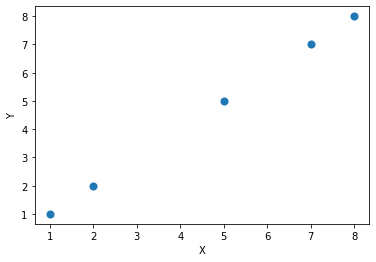

In [102]:
df.plot('X', 'Y', kind='scatter', s=50)

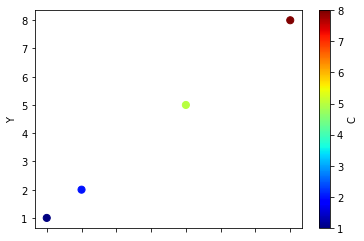

In [103]:
df.plot('X', 'Y', c='C', kind='scatter', cmap='jet', s=50)

In [135]:
x = df['X'].tolist()
y = df['Y'].tolist()
c = df['C'].tolist()

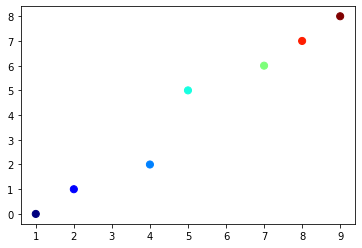

In [110]:
def delnan(arr):
    idxnan = np.where(np.isnan(arr))[0]
    return np.delete(arr, idxnan)

x1 = delnan(df['X'].tolist())
y1 = delnan(df['Y'].tolist())
c1 = delnan(df['C'].tolist())

plt.scatter(x1, y1, c=c1, cmap='jet', s=50)


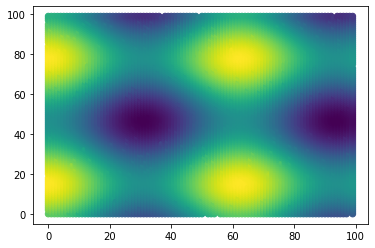

In [7]:
fig, ax = plt.subplots()
ax.scatter(df['X'], df['Y'], c=df['C'], cmap='viridis')

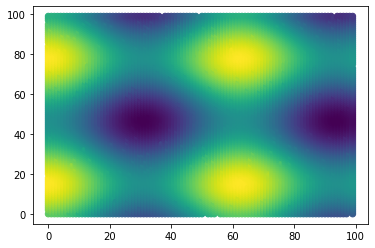

In [8]:
x = df['X'].values
y = df['Y'].values
c = df['C'].values

fig, ax = plt.subplots()
ax.scatter(x, y, c=c, cmap='viridis')

In [119]:
def chk_type(var, typename):
    """
    check type of variable
    
    Parameters
    ------------------------
    var : variable
    typename : (str)type name 
               'array' is regarded as 'list' as well.    
    """
    typename_tol = 'nullnullnull'
    
    if typename == 'list': typename_tol = 'array'
    if typename == 'array': typename_tol = 'list'
    
    if typename in str(type(var)) or typename_tol in str(type(var)):
        return True
    else:
        return False

In [130]:
type(set(x))

set

In [25]:
chk_type(x, 'array')

True

In [28]:
print(chk_type(x, 'float'))

AssertionError: 

In [128]:
from functools import reduce

def chk_nan(*args):
    data_names = []
    data = []
    data_nanidx = []
    data_new = []
    
    for i, arg in enumerate(args):
        # data should be array-like
        assert chk_type(arg, 'list') or chk_type(arg, 'array') or chk_type(arg, 'series'), "Only array-like data is acceptable"
        
        # data names
        if chk_type(arg, 'series'):
            data_names.append(arg.name)
        else: 
            data_names.append(f'data_{i}')
        
        # data
        data.append(np.array(arg))
            
        # null values
        data_nanidx.append(np.where(np.isnan(arg))[0])
        if len(data_nanidx[i]) > 0:
            print(f'# WARNING {data_names[i]}: Number of null values= {len(data_nanidx[i])} of {len(data[i])}.')

    # union indices of null values 
    data_nanidx_all = reduce(lambda a, b: list(set(a) | set(b)), data_nanidx)
    print(f'# Total number of missing data: {len(data_nanidx_all)}')
    
    for i, datum in enumerate(data):
        data_new.append(np.delete(data[i], data_nanidx_all))
    
    return data_new

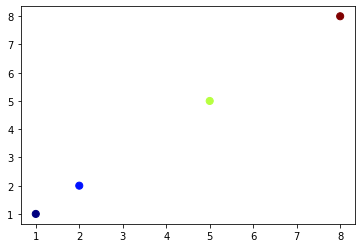

In [136]:
plt.scatter(x, y, c=c, cmap='jet', s=50)

ValueError: cannot convert float NaN to integer

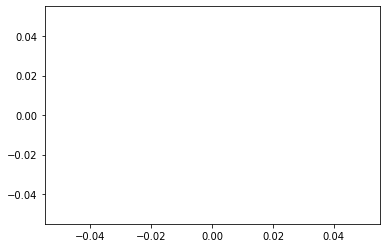

In [140]:
import seaborn as sns

sns.distplot(x)

# WARNING data_0: Number of null values= 3 of 10.
# WARNING data_1: Number of null values= 3 of 10.
# WARNING data_2: Number of null values= 3 of 10.
# Total number of missing data: 6


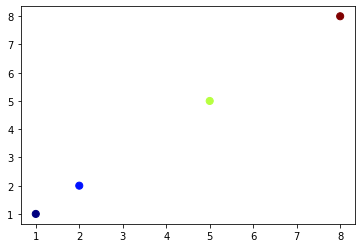

In [137]:
x2, y2, c2 = chk_nan(x, y, c)

plt.scatter(x2, y2, c=c2, cmap='jet', s=50)

In [129]:
x, y, c = chk_nan(df['X'], df['Y'], df['C'], df)

fig, ax = plt.subplots()
ax.scatter(x, y, c=c, cmap='viridis')

# WARNING X: Number of null values= 3 of 10.
# WARNING Y: Number of null values= 3 of 10.
# WARNING C: Number of null values= 3 of 10.


AssertionError: Only array-like data is acceptable

In [154]:
fonts ={
        "suptitle":{
            "family": "serif",
            "size": 22,
            "weight": "bold",
            "color": "gray",
            "verticalalignment": "baseline",
            "horizontalalignment": "center"
        },
        
        "title":{
            "family": "sans-serif",
            "size": 20,
            "color": "cornflowerblue",
            "weight": "bold",
            "verticalalignment": "baseline",
            "horizontalalignment": "center"
        },
        
        "label": {
            "family": "sans-serif",
            "size": 18,
            "color": "gray",
            "weight": "bold"
        },
        
        "negsub": {
            "fontname": "Liberation Sans",
            "horizontalalignment": "center"
        },
        
        "math": {
            "verticalalignment": "bottom",
            "horizontalalignment": "center"
        },
        "text": {
            "family": "sans-serif",
            "size": 18,
            "color": "gray",
            "weight": "bold",
            "verticalalignment": "baseline",
            "horizontalalignment": "center"
        }
    }

import matplotlib as mpl

# fontdicts
font_label = fonts['label']     # xlabel and ylabel
font_title = fonts['title']     # title
font_negsup = fonts['negsub']   # negative(-) on superscript 
font_math = fonts['math']       # math

# fontproperties:suptitle
font_suptitle = mpl.font_manager.FontProperties()
font_suptitle_ = fonts['suptitle']
font_suptitle.set_family(font_suptitle_['family'])
font_suptitle.set_size(font_suptitle_['size'])
font_suptitle.set_weight(font_suptitle_['weight'])

In [174]:
def plot_missings(df, labels=None, filename=None, 
                  figsize=None, color='lightcoral', text_y=None):
    """
    plot: numbers and types of missing data as bar type
    
    Parameters
    ------------------------
    df : (pd.DataFrame)
    labels : (dictionary) None.
             key: value = column name: label
             default  None. column names are shown.
    filename : (str) None: no file output.
               file name to save plot.
    figsize : (float, float) None: (ncols*0.5, 10)
              figure size in inch.
    color : (str) 'lightcoral'
            a member of matplots color list.
            https://matplotlib.org/3.2.1/gallery/color/named_colors.html#sphx-glr-gallery-color-named-colors-py
    text_y : (float) None: 10% of minimum, or 1e-3
             offset of texts on the figure.
    """
    columns = list(df.columns)
    counts = df.count()
    size = df.shape[0]
    types = df.dtypes.tolist()
    
    # text y position
    if text_y == None:
        text_ys = np.array(100 - counts/size*100)
        try:
            text_y = text_ys[np.where(text_ys >0)].min() * 0.1
        except:
            text_y = 1e-3
    
    # labels
    labels_str = dict(zip(columns, columns)) #데이터의 일부만 들어가도 동작
        
    # figure size
    if figsize == None:
        figsize = (df.shape[1]*0.5, 5)

    # plot
    fig, ax = plt.subplots(figsize=figsize)

    ax.bar(columns, (1-np.array(counts)/size)*100, color=color)

    ax.set_title(f'no. of total data = {size}', fontdict=font_title)
    ax.set_xlim(-0.5, len(columns)-0.5)
    ax.set_yscale('log')
    ax.set_ylim(text_y*0.5,)
    ax.set_xticklabels(labels_str, rotation=45, horizontalalignment='right')
    ax.set_xlabel(' ', fontdict=font_label)
    ax.set_ylabel(' ', fontdict=font_label)
    
    for i, count in enumerate(counts):
        ax.text(i, text_y, f'{size-count} ({(1-count/size)*100:0.2f}%) {types[i]}', 
                fontsize=12, color='k', rotation=90,
               horizontalalignment='center')

    fig.tight_layout()
    
    if filename != None:
        fig.savefig(f'./images/missings_{filename:s}.png')
    
    plt.show()

In [178]:
int(True)

1

In [175]:
size = 77

data = {}
for i in range(26):
    col = chr(ord('A')+i)
    data[col] = np.random.rand(size)
    nanidx = np.random.randint(0, size, size=randint(0,size))
    data[col][nanidx] = np.nan

df2 = pd.DataFrame.from_dict(data)

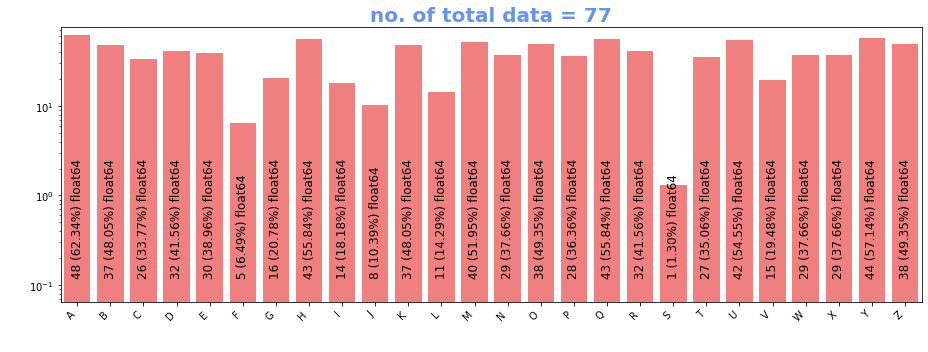

In [176]:
plot_missings(df2)

In [183]:
def cmp_dfs(df1, df2, key1, key2=None):
    """
    check type of variable
    
    Parameters
    ------------------------
    df1, df2   : (pandas.DataFrame)
    key1, key2 : (str) key column name of df1 and df2, respectively.
                 if key2 == None: key2 = key1
    """
    if key2 == None: key2 = key1
        
    assert key1 in df1.columns
    assert key2 in df2.columns
    
    dfkey1 = df1[key1].tolist()
    dfkey2 = df2[key2].tolist()

    df1_2 = list(set(dfkey1) - set(dfkey2))
    df2_1 = list(set(dfkey2) - set(dfkey1))
    df1n2 = list(set(dfkey1) & set(dfkey2))
    df1u2 = list(set(dfkey1) | set(dfkey2))
    
    print(f'# No. of df1= {df1.shape[0]}, df2= {df2.shape[0]}')
    print(f'- No. of [df1 - df2] = {len(df1_2)}')
    print(f'- No. of [df2 - df1] = {len(df2_1)}')
    print(f'- No. of [df1 & df2] = {len(df1n2)}')
    print(f'- No. of [df1 | df2] = {len(df1u2)}')
    
    return df1_2, df2_1, df1n2, df1u2

In [180]:
df1 = pd.DataFrame({'A':[1,2,3], 'B':[11,12,13]})
df2 = pd.DataFrame({'A':[1,2,4], 'D':[11,12,14]})

In [184]:
cmp_dfs(df1, df2, 'A')

# No. of df1= 3, df2= 3
- No. of [df1 - df2] = 1
- No. of [df2 - df1] = 1
- No. of [df1 & df2] = 2
- No. of [df1 | df2] = 4


([3], [4], [1, 2], [1, 2, 3, 4])